# 4.2 Distribution fitting

Fitting one family by hand, as 4.1 did, does not scale past "does normal look right".
`DistributionFitter` fits every registered family at once and marks the winner by two
different criteria that do not always agree — the disagreement is usually more
informative than either number alone.

In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from goad_toolkit.config import DataConfig, FileConfig
from goad_toolkit.dataprocessor import CovidDataProcessor
from goad_toolkit.models import linear_model, mse, train_model
from goad_toolkit.distributions import DistributionRegistry
from goad_toolkit.analytics import DistributionFitter, FitResult, fit_table
from goad_toolkit.visualizer import (
    ComparePlot,
    ECDFPlot,
    PlotFits,
    FitPlotSettings,
    PlotSettings,
    QQPlot,
    ResidualPlot,
)

from wa_analyzer.data import load_showcase

rng = np.random.default_rng(7)

## A model, so there is a residual to fit

Deaths from positive tests, lagged and z-scored — the same worked example goad's
"Models and residuals" chapter walks through (`goad_get_concept("models and
residuals")` via the `goad` MCP server). `CovidDataProcessor` downloads and caches the
raw series once; `train_model` fits `deaths ≈ a · positivetests + b`.

In [ ]:
processor = CovidDataProcessor(FileConfig(), DataConfig())
data = processor.process()
print(data.shape)
data.head(3)

In [3]:
X = data["positivetests"].to_numpy()
y = data["deaths_shifted"].to_numpy()

params = train_model(X, y, linear_model, mse, params=[0.01, 1.0], bounds=[(0, 1.0), (0, None)])
data["predicted"] = linear_model(X, params)
data["residual"] = y - data["predicted"]
print(f"fitted params (rate, offset): {params}")

fitted params (rate, offset): [6.10680643e-03 7.34722009e+00]


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Deaths: actual vs. predicted'}, xlabel='date', ylabel='deaths'>)

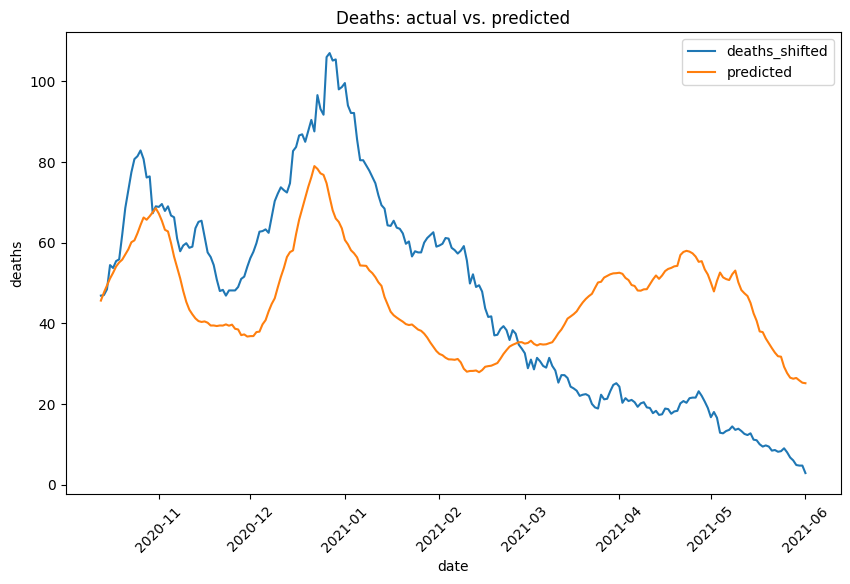

In [4]:
ComparePlot(PlotSettings(xlabel="date", ylabel="deaths", title="Deaths: actual vs. predicted")).plot(
    data=data, x="date", y1="deaths_shifted", y2="predicted",
)

(<Figure size 1100x400 with 1 Axes>,
 <Axes: title={'center': 'Residual over time'}, xlabel='date', ylabel='error'>)

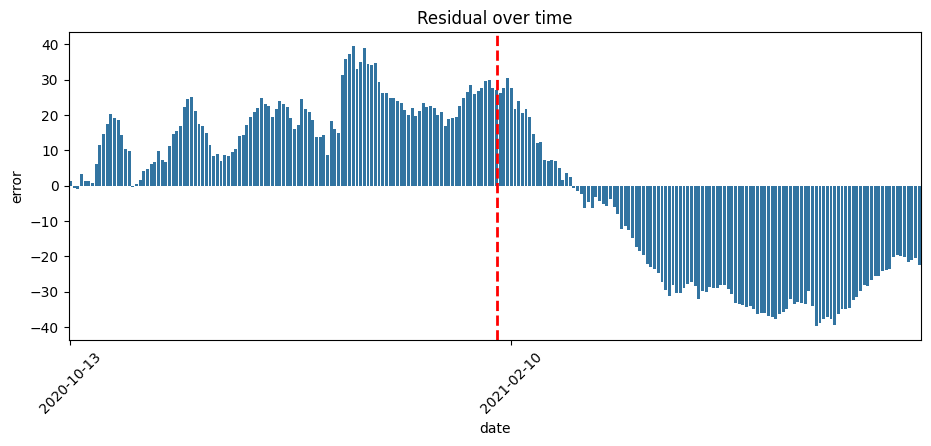

In [5]:
midpoint = str(data.index[len(data) // 2].date())
ResidualPlot(PlotSettings(figsize=(11, 4), xlabel="date", ylabel="error", title="Residual over time")).plot(
    data=data, x="date", y="residual", date=midpoint, datelabel="midpoint", interval=4,
)

No obvious drift or step — the model is not systematically wrong at any particular time.
That clears the first residual check goad's "Models and residuals" chapter walks
through (§6.3); what is left is the distribution of the error itself.

## Fit every family at once

`DistributionFitter().fit()` walks the whole registry and returns a `FitResult` or
`FailedFit` per family — no hand-written loop, no picking one family in advance.

In [6]:
residual = data["residual"].dropna().to_numpy()

registry = DistributionRegistry()
fitter = DistributionFitter(registry)
results = fitter.fit(residual, discrete=False)

table = fit_table(results)
table

,distribution,params,log_likelihood,ks_stat,ks_pvalue,best_likelihood,best_ks,message
0,uniform,"(-39.76414665057417, 79.26886657126593)",-1014.500144,0.101673,1.533106e-02,True,True,Optimization terminated successfully.
1,beta,"(1.554703695646118, 1.5542894325268137, -41.56...",-1029.941654,0.140935,1.751568e-04,False,False,Optimization terminated successfully.
2,weibull,"(6.159628487087181, -118.8927981452301, 128.46...",-1054.553988,0.143031,1.324085e-04,False,False,Optimization terminated successfully.
3,norm,"(-2.1537757729483454e-05, 23.50263962542359)",-1061.643652,0.136310,3.200126e-04,False,False,Optimization terminated successfully.
4,skewnorm,"(0.07408256280619023, -1.3933993824185662, 23....",-1061.644727,0.136391,3.167227e-04,False,False,Optimization terminated successfully.
5,gamma,"(8.829860301138249, -74.0666336838244, 8.36900...",-1068.392286,0.162734,7.769130e-06,False,False,Optimization terminated successfully.
6,lognorm,"(0.20872007318946076, -118.8927981452301, 116....",-1069.379266,0.156510,1.980784e-05,False,False,Optimization terminated successfully.
7,exponential,"(-39.75130989796217, 43.43954589080823)",-1087.259891,0.185781,1.753768e-07,False,False,Optimization terminated successfully.


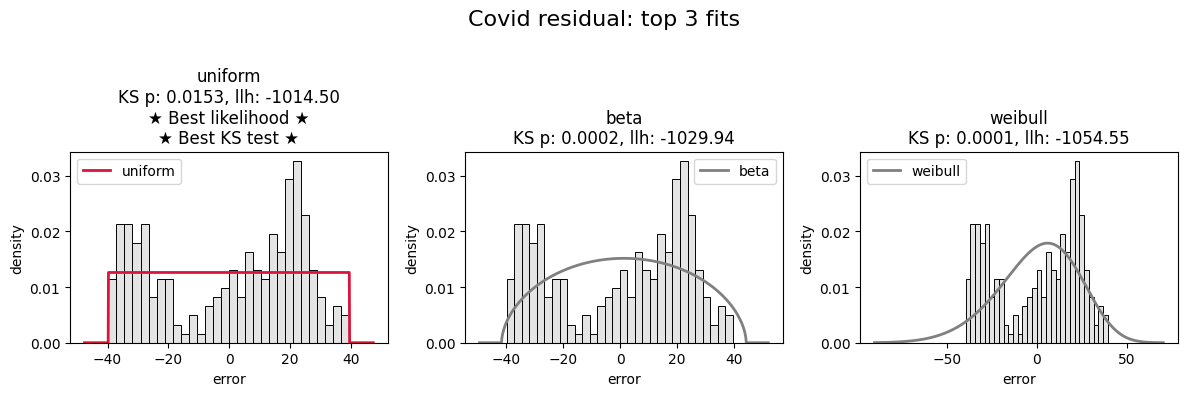

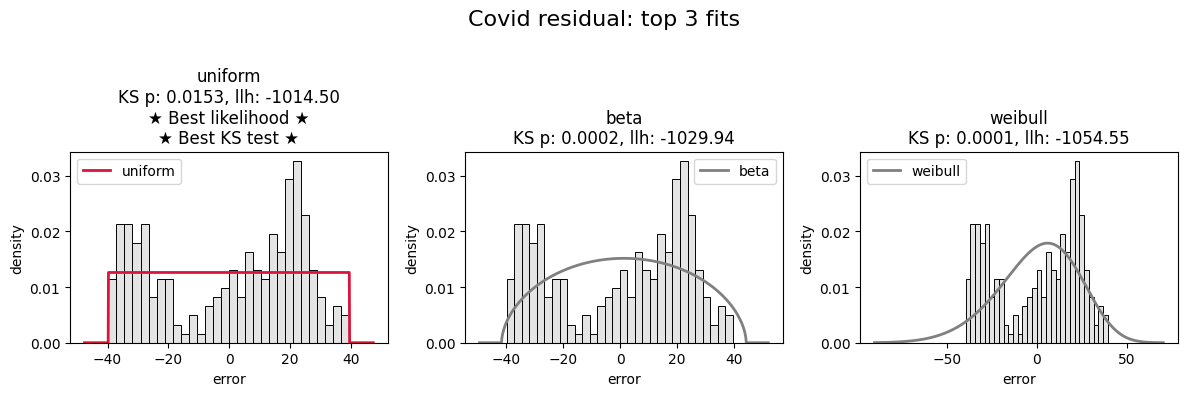

In [7]:
PlotFits(PlotSettings(figsize=(12, 4), xlabel="error", ylabel="density", title="Covid residual: top 3 fits")).plot(
    data=residual, fit_results=results, fitplotsettings=FitPlotSettings(bins=30, max_fits=3),
)

## Do log-likelihood and KS agree here?

Crimson panels are the best-by-likelihood family, dark blue the best-by-KS. When they are
the same panel, both criteria agree — which is not guaranteed, and not something to assume
from the picture. Check the actual numbers:

In [8]:
winners = table[(table["best_likelihood"]) | (table["best_ks"])]
print(winners[["distribution", "log_likelihood", "ks_pvalue", "best_likelihood", "best_ks"]])

by_ll = table.iloc[0]["distribution"]
by_ks = table.sort_values("ks_pvalue", ascending=False).iloc[0]["distribution"]
if by_ll == by_ks:
    print(f"\nBoth criteria agree on '{by_ll}' here.")
else:
    print(f"\nThey disagree: '{by_ll}' wins by log-likelihood, '{by_ks}' wins by KS.")
    print("Log-likelihood is dominated by the bulk of the data; KS is comparatively blind")
    print("in the tails. A disagreement is a hint to look at the qq-plot, not a tie-breaker")
    print("to average away.")

  distribution  log_likelihood  ks_pvalue  best_likelihood  best_ks
0      uniform    -1014.500144   0.015331             True     True

Both criteria agree on 'uniform' here.


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'residual vs. fitted uniform'}, xlabel='X', ylabel='Y'>)

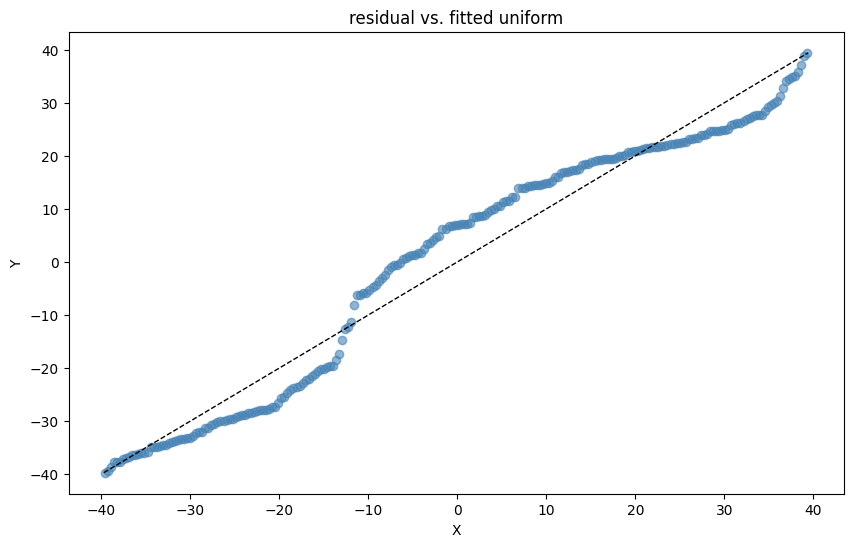

In [9]:
best_ll = next(r for r in results if isinstance(r, FitResult) and r.best_likelihood)
QQPlot(PlotSettings(title=f"residual vs. fitted {best_ll.distribution}")).plot(
    data=residual, distribution=best_ll.frozen_dist,
)

## The extensibility exercise: a family goad does not ship

`pareto` is deliberately not in the default registry (goad's "Distributions" chapter, §5.2,
explains why) — lesson 4 registers it as the concrete case for "the shipped set is not the
ceiling". Author *message counts* in the IRC corpus is the natural candidate: a "rich get
richer" variable if there ever was one.

In [10]:
irc = load_showcase("ubuntu_irc")
authors = Counter()
pattern = re.compile(r"^\[\d{2}:\d{2}\] <([^>]+)>", flags=re.MULTILINE)
for text in irc["text"]:
    for m in pattern.finditer(text):
        authors[m.group(1)] += 1

author_counts = pd.Series(authors).sort_values(ascending=False).to_numpy().astype(float)
print(f"{len(author_counts)} authors, busiest sent {author_counts.max():.0f} messages, median {np.median(author_counts):.0f}")

4740 authors, busiest sent 48045 messages, median 5


In [11]:
before = fit_table(DistributionFitter(DistributionRegistry()).fit(author_counts, discrete=False))
before[["distribution", "log_likelihood", "ks_pvalue", "best_likelihood", "best_ks"]]

2026-08-11 22:25:47.577 | WARNING  | goad_toolkit.analytics:fit_distribution:183 - Fitting failed: Optimization converged to parameter values that are inconsistent with the data.


2026-08-11 22:25:48.677 | WARNING  | goad_toolkit.analytics:fit_distribution:183 - Fitting failed: Optimization converged to parameter values that are inconsistent with the data.


,distribution,log_likelihood,ks_pvalue,best_likelihood,best_ks
0,gamma,2869.829425,0.000000e+00,True,False
1,weibull,1904.534636,2.442153e-307,False,True
2,lognorm,-436.383296,0.000000e+00,False,False
3,exponential,-27772.963805,0.000000e+00,False,False
4,skewnorm,-37961.339585,0.000000e+00,False,False
5,norm,-40962.639259,0.000000e+00,False,False
6,uniform,NaN,NaN,False,False
7,beta,NaN,NaN,False,False


In [12]:
extended = DistributionRegistry()
extended.register_distribution("pareto", stats.pareto, is_discrete=False, num_params=3)

extended_results = DistributionFitter(extended).fit(author_counts, discrete=False)
after = fit_table(extended_results)
after[["distribution", "log_likelihood", "ks_pvalue", "best_likelihood", "best_ks"]]

2026-08-11 22:25:48.735 | WARNING  | goad_toolkit.analytics:fit_distribution:183 - Fitting failed: Optimization converged to parameter values that are inconsistent with the data.


2026-08-11 22:25:49.827 | WARNING  | goad_toolkit.analytics:fit_distribution:183 - Fitting failed: Optimization converged to parameter values that are inconsistent with the data.


,distribution,log_likelihood,ks_pvalue,best_likelihood,best_ks
0,gamma,2869.798763,0.000000e+00,True,False
1,weibull,1904.447539,1.205520e-303,False,False
2,lognorm,-437.103835,0.000000e+00,False,False
3,pareto,-18419.379468,3.268621e-252,False,True
4,exponential,-27817.311044,0.000000e+00,False,False
5,skewnorm,-37961.339591,0.000000e+00,False,False
6,norm,-40962.639393,0.000000e+00,False,False
7,uniform,NaN,NaN,False,False
8,beta,NaN,NaN,False,False


Registering `pareto` does not dethrone the likelihood winner — the bulk of authors sending
a handful of messages is still fit better by a gamma shape overall. But it does take the KS
crown: none of these fits are good in an absolute sense (every KS p-value here is
essentially zero — reject-everything territory typical of a dataset this size), but
relative to each other, `pareto` tracks the empirical CDF more closely than anything that
was in the registry before it existed to compete. That is the honest version of "the
shipped set was missing something": not a clean win, a *different and more informative*
disagreement between the two criteria than existed before.

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Author message counts: empirical vs. a pareto sample of the same size'}, xlabel='X', ylabel='Y'>)

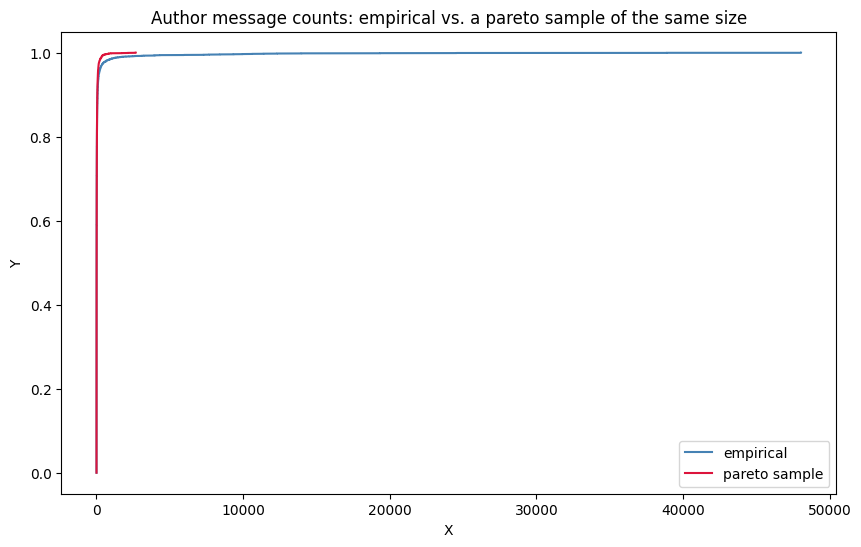

In [13]:
pareto_fit = next(r for r in extended_results if r.distribution == "pareto")
synthetic = pareto_fit.frozen_dist.rvs(len(author_counts), random_state=rng)

ECDFPlot(PlotSettings(title="Author message counts: empirical vs. a pareto sample of the same size")).plot(
    data=author_counts, compare=synthetic, label="empirical", compare_label="pareto sample",
)

The rank-frequency version of the same claim — the visual discriminator goad's
"Distributions" chapter (§5.7) recommends when a histogram cannot settle it:

Text(0.5, 1.0, 'Author activity, by rank')

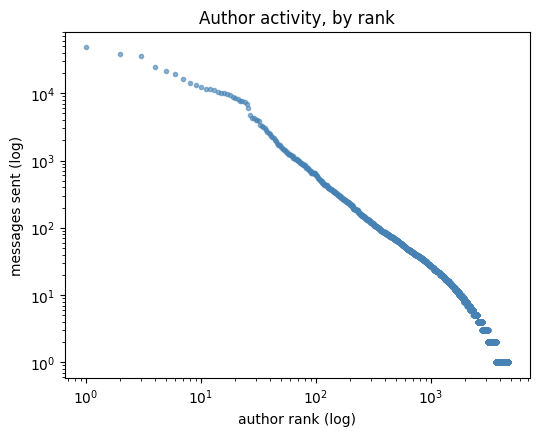

In [14]:
rank = np.arange(1, len(author_counts) + 1)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(rank, author_counts, ".", color="steelblue", alpha=0.6)
ax.set_xlabel("author rank (log)")
ax.set_ylabel("messages sent (log)")
ax.set_title("Author activity, by rank")

Straight-ish over several orders of magnitude — the visual signature the fit numbers above
were quietly disagreeing about.

## Reflection

1. In your own words: why does `DistributionFitter` mark a *likelihood* winner and a *KS*
   winner separately, instead of one combined score?
2. The pareto exercise above did not produce a clean "pareto wins" result. Is that a failure
   of the exercise, or exactly the point? Defend your answer with the actual numbers, not
   the vibe of the plot.
3. Pick one distribution from the registry that is not `pareto` and name a real variable —
   from any lesson so far — you would register it for, if it were also missing.